# *Google Play Store dataset*

**lets gooooooooooooooooooooooo*

In [22]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
data = pd.read_csv('googleplaystore.csv')

## Understand the basics related to dataset

In [24]:
df = data.copy()
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### **What is the shape of the dataset?*

In [25]:
df.shape

(10841, 13)

What are the data types of all columns? and Find out the name of all the columns

In [26]:
df.dtypes


App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

Which columns contain missing values?

In [27]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

What percentage of values are missing in each column?

In [28]:
(df.isnull().sum()/len(df))*100

App                0.000000
Category           0.000000
Rating            13.596532
Reviews            0.000000
Size               0.000000
Installs           0.000000
Type               0.009224
Price              0.000000
Content Rating     0.009224
Genres             0.000000
Last Updated       0.000000
Current Ver        0.073794
Android Ver        0.027673
dtype: float64

Find out the numerical  columns and categorical columns separately

In [29]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


How many duplicate rows exist?

In [30]:
df.duplicated().sum()

np.int64(483)

Which apps appear more than once?

In [31]:
dup= df[df.duplicated(subset='App', keep=False)]
dup.sort_values('App')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3202,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3118,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
3103,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,Varies with device,"50,000,000+",Free,0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device
8291,wetter.com - Weather and Radar,WEATHER,4.2,189310,38M,"10,000,000+",Free,0,Everyone,Weather,"August 6, 2018",Varies with device,Varies with device


Are there apps with invalid ratings (>5 or <1)?

In [32]:
inv = df[(df['Rating'] > 5) | (df['Rating'] < 1)]
inv

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


Are there categories with only a few observations?

Category
1.9    1
Name: count, dtype: int64


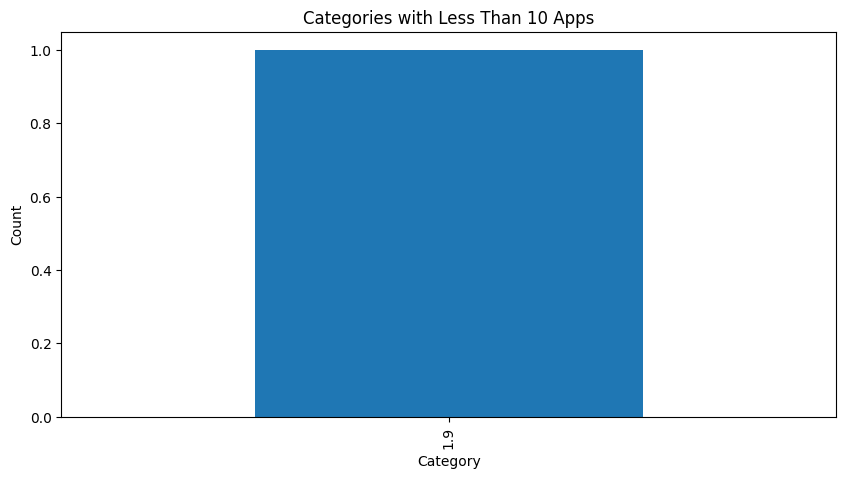

In [33]:
cat = df['Category'].value_counts()
few = cat[cat < 10]
print(few)
plt.figure(figsize=(10,5))
few.plot(kind='bar')
plt.title("Categories with Less Than 10 Apps")
plt.ylabel("Count")
plt.show()

Convert Reviews, Installs, Size, and Price into numeric form.

In [34]:
# Reviews
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Installs
df['Installs'] = (
    df['Installs']
      .astype(str)
      .str.replace(',', '', regex=False)
      .str.replace('+', '', regex=False)
)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Size
def convert_size(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if x.endswith('M'):
        return float(x[:-1])
    elif x.endswith('k'):
        return float(x[:-1]) / 1024
    else:
        return np.nan

df['Size'] = df['Size'].apply(convert_size)

# Price
df['Price'] = (
    df['Price']
      .astype(str)
      .str.replace('$', '', regex=False)
)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df[['Reviews','Installs','Size','Price']].head()

,Reviews,Installs,Size,Price
0,159.0,10000.0,19.0,0.0
1,967.0,500000.0,14.0,0.0
2,87510.0,5000000.0,8.7,0.0
3,215644.0,50000000.0,25.0,0.0
4,967.0,100000.0,2.8,0.0


How many apps have zero reviews?

In [35]:
(df['Reviews'] == 0).sum()

np.int64(596)

How are ratings distributed? and Explain within markdown what u understood from this distribution

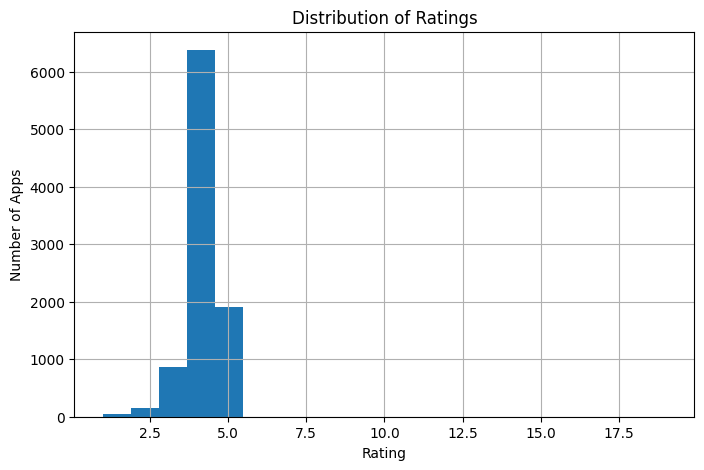

In [36]:
plt.figure(figsize=(8,5))

df['Rating'].hist(bins=20)

plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.title("Distribution of Ratings")
plt.show()

Most applications are rated between 4.0 and 4.6 stars.
Very few apps have ratings below 3.0. 
most apps on the Google Play Store are well rated by users.

Are ratings normally distributed?

In [37]:
from scipy.stats import shapiro

ratings = df['Rating'].dropna()

sample = ratings.sample(min(5000, len(ratings)), random_state=42)

stat, p = shapiro(sample)

print("Shapiro Statistic:", stat)
print("p-value:", p)

if p > 0.05:
    print("Ratings appear normally distributed.")
else:
    print("Ratings are NOT normally distributed.")

Shapiro Statistic: 0.8661014013373082
p-value: 3.003044685642325e-54
Ratings are NOT normally distributed.


Ratings are concentrated around higher values (4–4.6), creating a skewed distribution rather than a bell-shaped curve.

Which rating range contains most apps?

In [38]:
bins = [0,1,2,3,4,5]

rating_ranges = pd.cut(df['Rating'], bins=bins)

rating_ranges.value_counts().sort_index()

Rating
(0, 1]      16
(1, 2]      52
(2, 3]     302
(3, 4]    2196
(4, 5]    6800
Name: count, dtype: int64

What is the average app size?

In [39]:
print("Average App Size (MB):", round(df['Size'].mean(),2))

Average App Size (MB): 21.52


How are app sizes distributed?

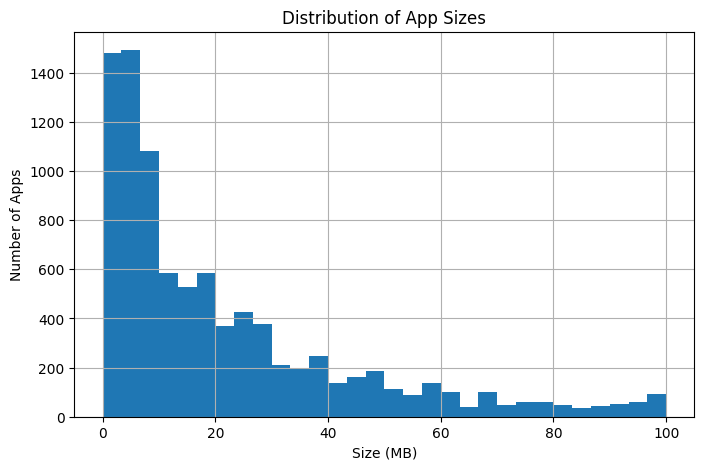

In [40]:
plt.figure(figsize=(8,5))

df['Size'].dropna().hist(bins=30)

plt.xlabel("Size (MB)")
plt.ylabel("Number of Apps")
plt.title("Distribution of App Sizes")
plt.show()

In [41]:
Explain....

SyntaxError: invalid syntax (1779154434.py, line 1)

Which content rating category is most common?

Content Rating
Everyone           8714
Teen               1208
Mature 17+          499
Everyone 10+        414
Adults only 18+       3
Unrated               2
Name: count, dtype: int64


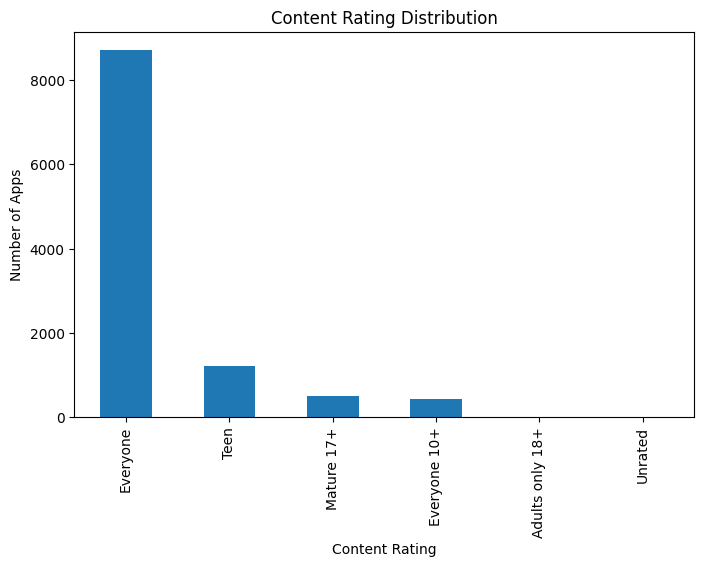

In [22]:
content_counts = df['Content Rating'].value_counts()

print(content_counts)

plt.figure(figsize=(8,5))
content_counts.plot(kind='bar')
plt.title("Content Rating Distribution")
plt.ylabel("Number of Apps")
plt.show()

What percentage of apps are free?

In [23]:
free_percent = (df['Type'] == 'Free').mean() * 100

print(f"Free Apps: {free_percent:.2f}%")

Free Apps: 92.60%


What percentage are paid?

In [24]:
paid_percent = (df['Type'] == 'Paid').mean() * 100

print(f"Paid Apps: {paid_percent:.2f}%")

Paid Apps: 7.38%


What is the maximum price of an app?

In [26]:
print("Maximum Price: $", df['Price'].max())

Maximum Price: $ 400.0


Which category contains the largest number of apps?

Category
FAMILY      1972
GAME        1144
TOOLS        843
MEDICAL      463
BUSINESS     460
Name: count, dtype: int64


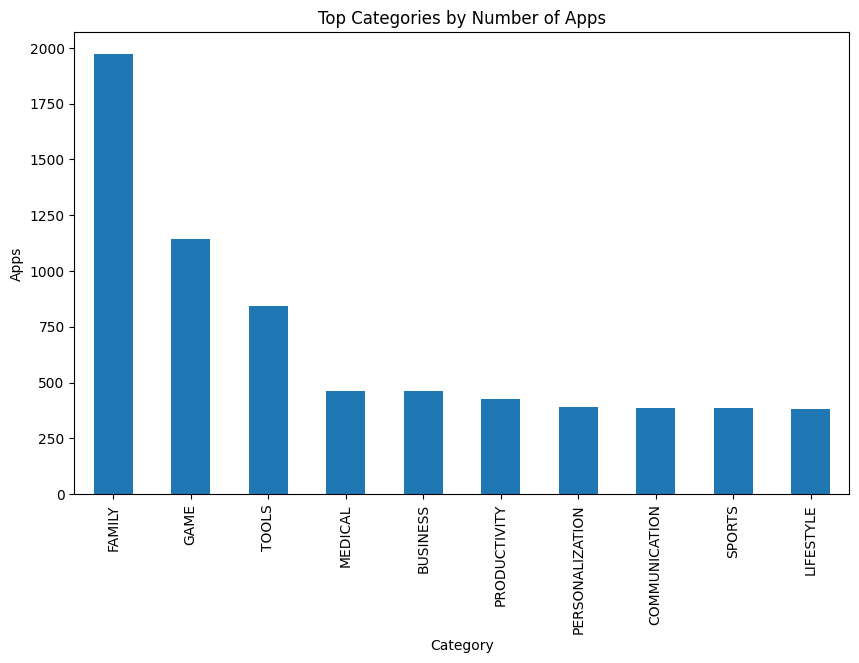

In [27]:
category_counts = df['Category'].value_counts()

print(category_counts.head())

plt.figure(figsize=(10,6))
category_counts.head(10).plot(kind='bar')
plt.title("Top Categories by Number of Apps")
plt.ylabel("Apps")
plt.show()

Which category contains the fewest apps?

In [28]:
fewest = df['Category'].value_counts().sort_values()

print(fewest.head(10))

Category
1.9                    1
BEAUTY                53
COMICS                60
PARENTING             60
EVENTS                64
ART_AND_DESIGN        65
WEATHER               82
AUTO_AND_VEHICLES     85
LIBRARIES_AND_DEMO    85
HOUSE_AND_HOME        88
Name: count, dtype: int64


Which category has the highest average rating?

In [29]:
avg_rating = (
    df.groupby('Category')['Rating']
      .mean()
      .sort_values(ascending=False)
)

print(avg_rating.head(10))

Category
1.9                    19.000000
EVENTS                  4.435556
EDUCATION               4.389032
ART_AND_DESIGN          4.358065
BOOKS_AND_REFERENCE     4.346067
PERSONALIZATION         4.335987
PARENTING               4.300000
GAME                    4.286326
BEAUTY                  4.278571
HEALTH_AND_FITNESS      4.277104
Name: Rating, dtype: float64


Which category has the lowest average rating?

In [30]:
avg_rating = (
    df.groupby('Category')['Rating']
      .mean()
      .sort_values()
)

print(avg_rating.head(10))

Category
DATING                 3.970769
TOOLS                  4.047411
MAPS_AND_NAVIGATION    4.051613
VIDEO_PLAYERS          4.063750
LIFESTYLE              4.094904
TRAVEL_AND_LOCAL       4.109292
BUSINESS               4.121452
ENTERTAINMENT          4.126174
FINANCE                4.131889
NEWS_AND_MAGAZINES     4.132189
Name: Rating, dtype: float64


Which category receives the highest total number of reviews?

Category
GAME               1.585422e+09
COMMUNICATION      8.154623e+08
SOCIAL             6.212414e+08
FAMILY             4.102263e+08
TOOLS              2.731850e+08
PHOTOGRAPHY        2.135166e+08
SHOPPING           1.150412e+08
PRODUCTIVITY       1.141170e+08
VIDEO_PLAYERS      1.103802e+08
PERSONALIZATION    8.934614e+07
Name: Reviews, dtype: float64


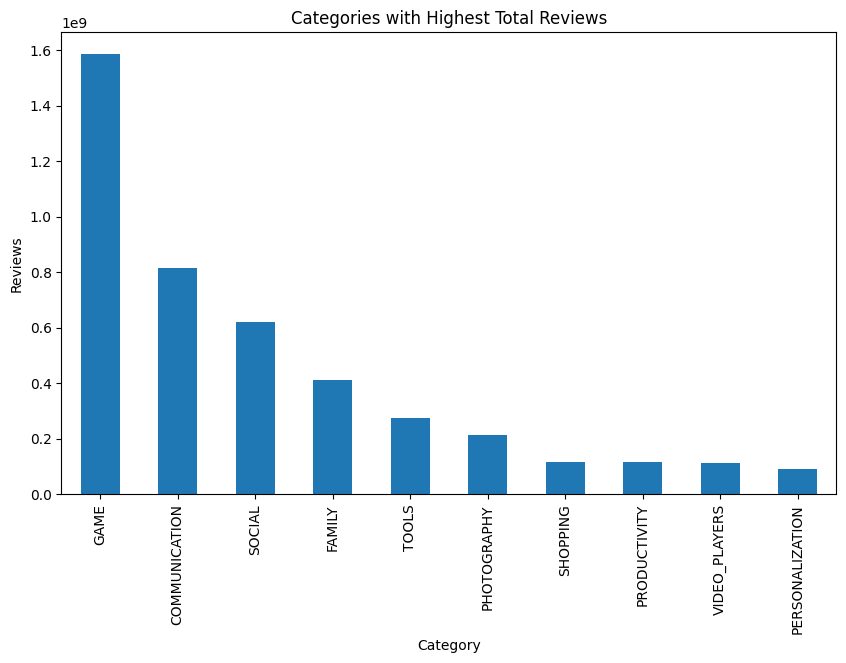

In [31]:
reviews = (
    df.groupby('Category')['Reviews']
      .sum()
      .sort_values(ascending=False)
)

print(reviews.head(10))

plt.figure(figsize=(10,6))
reviews.head(10).plot(kind='bar')
plt.title("Categories with Highest Total Reviews")
plt.ylabel("Reviews")
plt.show()

Which category has the highest average installs?

In [32]:
installs = (
    df.groupby('Category')['Installs']
      .mean()
      .sort_values(ascending=False)
)

print(installs.head(10))

Category
COMMUNICATION         8.435989e+07
SOCIAL                4.769447e+07
VIDEO_PLAYERS         3.555430e+07
PRODUCTIVITY          3.343418e+07
GAME                  3.066960e+07
PHOTOGRAPHY           3.011417e+07
TRAVEL_AND_LOCAL      2.662359e+07
NEWS_AND_MAGAZINES    2.648876e+07
ENTERTAINMENT         1.925611e+07
TOOLS                 1.358573e+07
Name: Installs, dtype: float64


Which category has the largest app sizes?

In [33]:
sizes = (
    df.groupby('Category')['Size']
      .mean()
      .sort_values(ascending=False)
)

print(sizes.head(10))

Category
GAME                  44.370065
FAMILY                28.319023
TRAVEL_AND_LOCAL      24.654463
SPORTS                24.338822
HEALTH_AND_FITNESS    22.768851
PARENTING             22.512963
FOOD_AND_DRINK        22.185000
ENTERTAINMENT         21.853333
EDUCATION             20.790600
AUTO_AND_VEHICLES     20.036807
Name: Size, dtype: float64


Which category contains the most paid apps?

In [34]:
paid_apps = (
    df[df['Type'] == 'Paid']
      .groupby('Category')
      .size()
      .sort_values(ascending=False)
)

print(paid_apps.head(10))

Category
FAMILY                 191
MEDICAL                109
PERSONALIZATION         83
GAME                    83
TOOLS                   78
BOOKS_AND_REFERENCE     28
PRODUCTIVITY            28
COMMUNICATION           27
SPORTS                  24
PHOTOGRAPHY             22
dtype: int64


Which category contains the highest percentage of free apps?

In [36]:
free_percent = (
    df.groupby('Category')['Type']
      .apply(lambda x: (x == 'Free').mean() * 100)
      .sort_values(ascending=False)
)

print(free_percent.head(10))

Category
COMICS                100.000000
BEAUTY                100.000000
HOUSE_AND_HOME        100.000000
NEWS_AND_MAGAZINES     99.293286
SHOPPING               99.230769
SOCIAL                 98.983051
LIBRARIES_AND_DEMO     98.823529
ENTERTAINMENT          98.657718
EVENTS                 98.437500
FOOD_AND_DRINK         98.425197
Name: Type, dtype: float64


Are certain categories dominated by a single content rating?

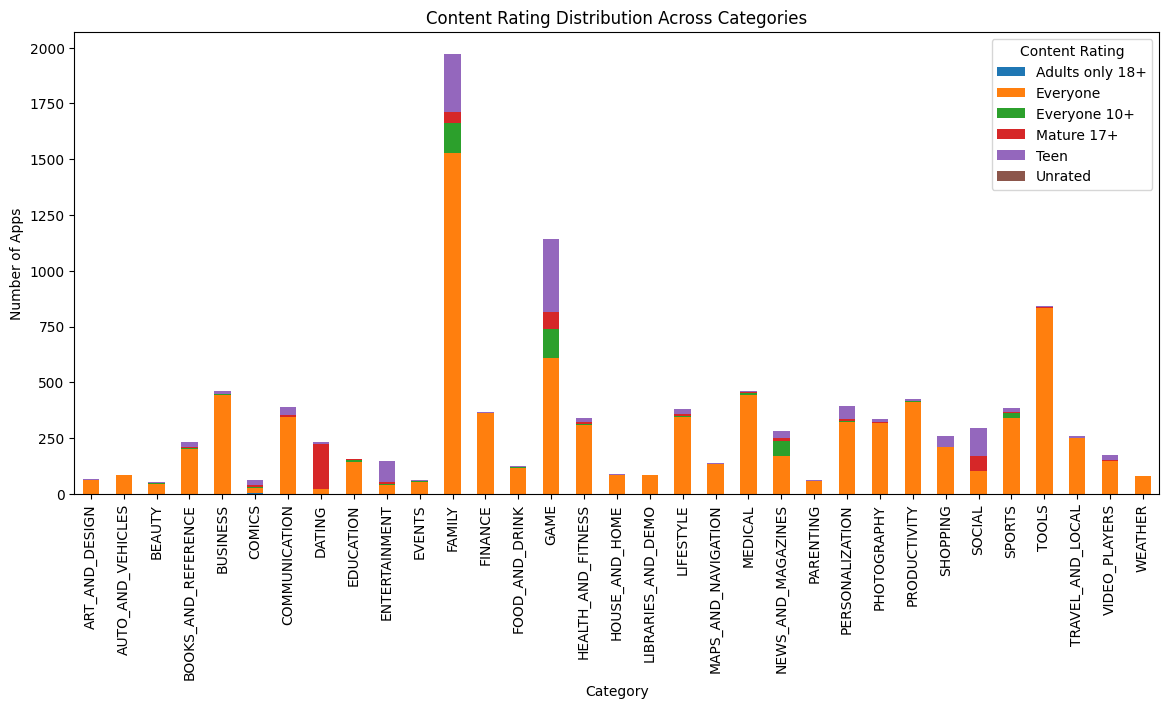

In [42]:
content_category = pd.crosstab(df['Category'], df['Content Rating'])

content_category.plot(
    kind='bar',
    stacked=True,
    figsize=(14,6)
)

plt.title("Content Rating Distribution Across Categories")
plt.ylabel("Number of Apps")
plt.show()

What are the top 20 highest-rated apps?

In [43]:
top_rated = (
    df[['App', 'Category', 'Rating']]
    .dropna()
    .sort_values('Rating', ascending=False)
    .head(20)
)

top_rated

,App,Category,Rating
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0
5246,Hey AJ! It's Bedtime!,FAMILY,5.0
6593,BP Journal - Blood Pressure Diary,MEDICAL,5.0
6604,BP Log lite,LIFESTYLE,5.0
10776,Monster Ride Pro,GAME,5.0
9061,Cloud DX Connected Health,HEALTH_AND_FITNESS,5.0
8955,DV ASSIST,FAMILY,5.0
9899,EU Exit poll,LIFESTYLE,5.0
9002,DW Security,BUSINESS,5.0
6646,Bar-B-Q Rib House,FOOD_AND_DRINK,5.0


Which category contributes most of the 5-star apps?

In [44]:
five_star = df[df['Rating'] == 5]

five_star['Category'].value_counts()

Category
FAMILY                 67
LIFESTYLE              29
MEDICAL                28
BUSINESS               18
TOOLS                  17
GAME                   12
HEALTH_AND_FITNESS     12
PERSONALIZATION        10
SOCIAL                  8
FINANCE                 8
PRODUCTIVITY            8
NEWS_AND_MAGAZINES      7
DATING                  6
EVENTS                  6
BOOKS_AND_REFERENCE     6
PHOTOGRAPHY             6
SHOPPING                6
COMMUNICATION           5
SPORTS                  4
TRAVEL_AND_LOCAL        3
COMICS                  2
LIBRARIES_AND_DEMO      2
FOOD_AND_DRINK          2
PARENTING               1
ART_AND_DESIGN          1
Name: count, dtype: int64

Do apps with more reviews receive higher ratings?

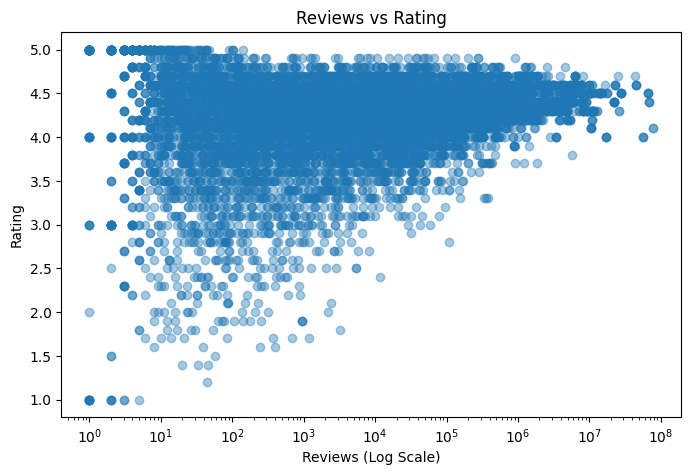

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Reviews'],
    df['Rating'],
    alpha=0.4
)

plt.xscale("log")

plt.xlabel("Reviews (Log Scale)")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")
plt.show()

Do highly installed apps have better ratings?

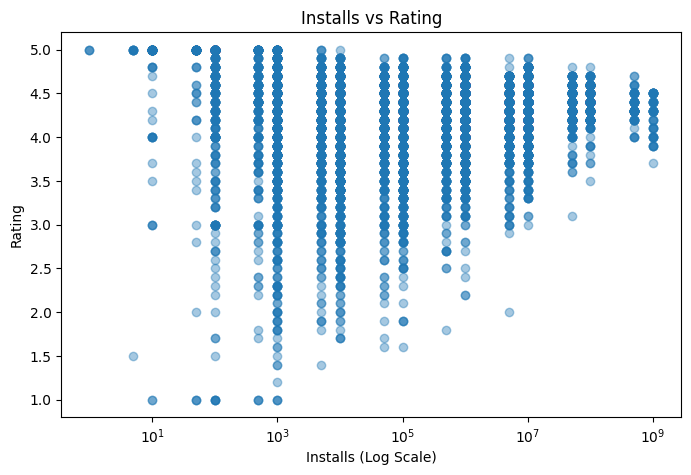

In [46]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Installs'],
    df['Rating'],
    alpha=0.4
)

plt.xscale("log")

plt.xlabel("Installs (Log Scale)")
plt.ylabel("Rating")
plt.title("Installs vs Rating")
plt.show()

Which category has the greatest variation in ratings?

In [47]:
rating_std = (
    df.groupby('Category')['Rating']
      .std()
      .sort_values(ascending=False)
)

rating_std.head(10)

Category
LIFESTYLE             0.693907
MEDICAL               0.663581
FINANCE               0.642108
DATING                0.630510
BUSINESS              0.624422
HEALTH_AND_FITNESS    0.617822
TOOLS                 0.616143
VIDEO_PLAYERS         0.551098
FOOD_AND_DRINK        0.548070
AUTO_AND_VEHICLES     0.543692
Name: Rating, dtype: float64

Are ratings different between free and paid apps?

<Figure size 700x500 with 0 Axes>

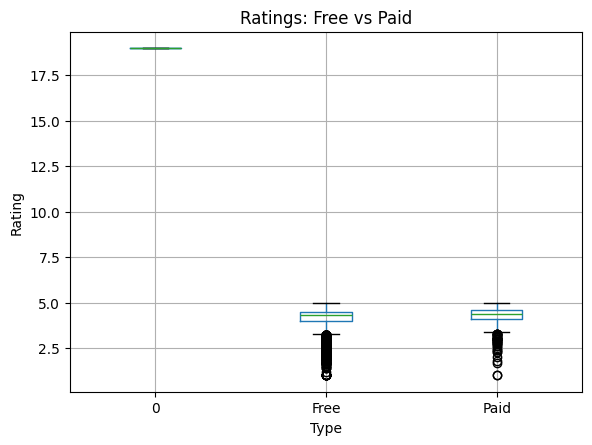

In [48]:
plt.figure(figsize=(7,5))

df.boxplot(column='Rating', by='Type')

plt.title("Ratings: Free vs Paid")
plt.suptitle("")
plt.ylabel("Rating")
plt.show()

Which apps have the highest installs?

In [49]:
top_installs = (
    df[['App','Installs']]
    .sort_values('Installs', ascending=False)
    .head(20)
)

top_installs

,App,Installs
1654,Subway Surfers,1.000000e+09
382,Messenger – Text and Video Chat for Free,1.000000e+09
451,Gmail,1.000000e+09
4098,Maps - Navigate & Explore,1.000000e+09
1917,Subway Surfers,1.000000e+09
3904,WhatsApp Messenger,1.000000e+09
3232,Google Street View,1.000000e+09
464,Hangouts,1.000000e+09
3523,Google Drive,1.000000e+09
2808,Google Photos,1.000000e+09


Do larger apps tend to have higher ratings?

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Size'],
    df['Rating'],
    alpha=0.4
)

plt.xlabel("Size (MB)")
plt.ylabel("Rating")
plt.title("App Size vs Rating")
plt.show()

Are older apps rated differently than recently updated apps?

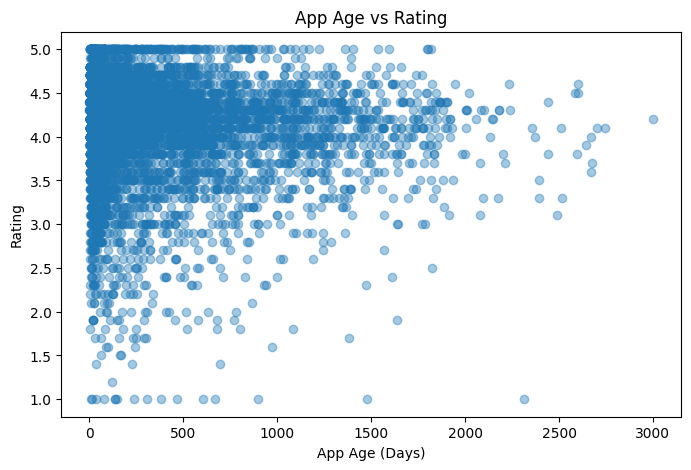

In [50]:
df['Last Updated'] = pd.to_datetime(
    df['Last Updated'],
    errors='coerce'
)

latest_date = df['Last Updated'].max()

df['App Age'] = (
    latest_date - df['Last Updated']
).dt.days

plt.figure(figsize=(8,5))

plt.scatter(
    df['App Age'],
    df['Rating'],
    alpha=0.4
)

plt.xlabel("App Age (Days)")
plt.ylabel("Rating")
plt.title("App Age vs Rating")
plt.show()

Which category has the most consistent ratings?

In [51]:
consistent = (
    df.groupby('Category')['Rating']
      .std()
      .sort_values()
)

consistent.head(10)

Category
EDUCATION             0.251894
ENTERTAINMENT         0.302556
WEATHER               0.331353
PERSONALIZATION       0.352732
ART_AND_DESIGN        0.358297
BEAUTY                0.362603
GAME                  0.365375
HOUSE_AND_HOME        0.368411
LIBRARIES_AND_DEMO    0.378522
SHOPPING              0.404577
Name: Rating, dtype: float64

Which category contributes the highest total installs?

In [52]:
category_installs = (
    df.groupby('Category')['Installs']
      .sum()
      .sort_values(ascending=False)
)

category_installs.head(10)

Category
GAME                  3.508602e+10
COMMUNICATION         3.264728e+10
PRODUCTIVITY          1.417609e+10
SOCIAL                1.406987e+10
TOOLS                 1.145277e+10
FAMILY                1.025826e+10
PHOTOGRAPHY           1.008825e+10
NEWS_AND_MAGAZINES    7.496318e+09
TRAVEL_AND_LOCAL      6.868887e+09
VIDEO_PLAYERS         6.222003e+09
Name: Installs, dtype: float64

What is the relationship between reviews and ratings?

In [53]:
df.groupby('Type')['Installs'].mean()

Type
0                NaN
Free    1.669095e+07
Paid    9.119510e+04
Name: Installs, dtype: float64

Do paid apps receive fewer installs than free apps?

In [57]:
df.groupby('Type')['Installs'].mean()

Type
0                NaN
Free    1.669095e+07
Paid    9.119510e+04
Name: Installs, dtype: float64

What percentage of apps have fewer than 10,000 installs?

In [56]:
percentage = (
    (df['Installs'] < 10000).mean()
) * 100

print(f"{percentage:.2f}%")

29.41%


Are highly-rated apps downloaded more frequently?

            Rating  Installs
Rating    1.000000  0.051355
Installs  0.051355  1.000000


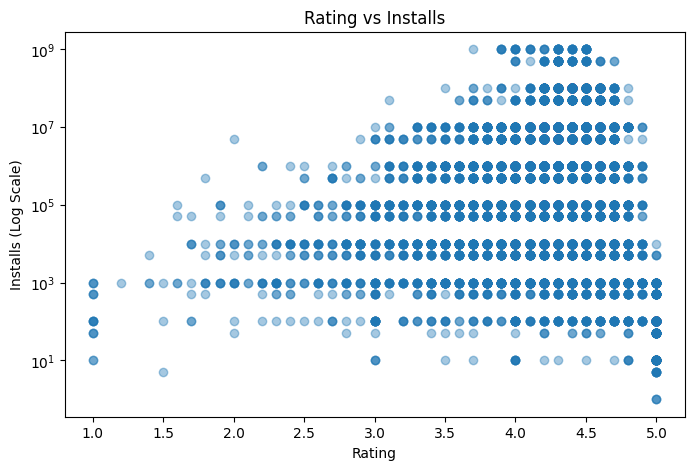

In [58]:
corr = df[['Rating', 'Installs']].corr()

print(corr)

plt.figure(figsize=(8,5))
plt.scatter(df['Rating'], df['Installs'], alpha=0.4)
plt.yscale('log')
plt.xlabel("Rating")
plt.ylabel("Installs (Log Scale)")
plt.title("Rating vs Installs")
plt.show()

Which content-rating group has the highest installs?

Content Rating
Everyone           1.141567e+11
Teen               3.471635e+10
Everyone 10+       1.323388e+10
Mature 17+         5.524491e+09
Adults only 18+    2.000000e+06
Unrated            5.050000e+04
Name: Installs, dtype: float64


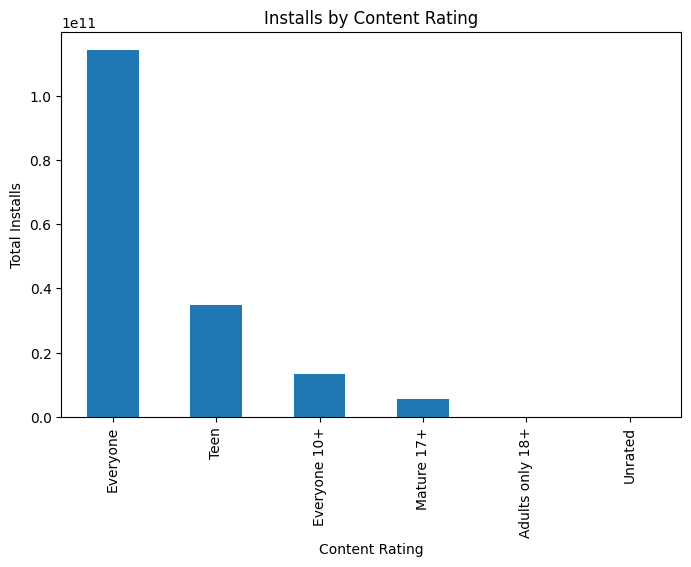

In [59]:
content_installs = (
    df.groupby('Content Rating')['Installs']
      .sum()
      .sort_values(ascending=False)
)

print(content_installs)

plt.figure(figsize=(8,5))
content_installs.plot(kind='bar')
plt.ylabel("Total Installs")
plt.title("Installs by Content Rating")
plt.show()

Which category contains the greatest number of apps with over 1 million installs?

In [60]:
million_apps = df[df['Installs'] >= 1_000_000]

million_apps['Category'].value_counts()

Category
GAME                   737
FAMILY                 651
TOOLS                  289
PHOTOGRAPHY            226
COMMUNICATION          212
PRODUCTIVITY           197
SPORTS                 174
SHOPPING               161
HEALTH_AND_FITNESS     156
SOCIAL                 156
ENTERTAINMENT          132
TRAVEL_AND_LOCAL       132
PERSONALIZATION        126
NEWS_AND_MAGAZINES     112
FINANCE                111
EDUCATION              108
BUSINESS                97
VIDEO_PLAYERS           95
LIFESTYLE               89
FOOD_AND_DRINK          63
BOOKS_AND_REFERENCE     61
MAPS_AND_NAVIGATION     60
DATING                  58
WEATHER                 45
HOUSE_AND_HOME          43
MEDICAL                 26
AUTO_AND_VEHICLES       18
COMICS                  18
PARENTING               15
LIBRARIES_AND_DEMO      14
ART_AND_DESIGN          13
BEAUTY                  10
EVENTS                   6
Name: count, dtype: int64

Are installs concentrated among a few apps?

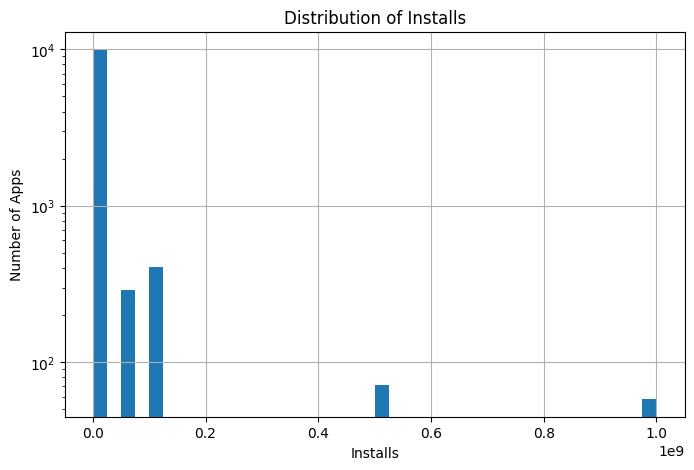

In [61]:
plt.figure(figsize=(8,5))

df['Installs'].hist(
    bins=40,
    log=True
)

plt.xlabel("Installs")
plt.ylabel("Number of Apps")
plt.title("Distribution of Installs")
plt.show()

What is the average price of paid apps?

In [62]:
paid = df[df['Type'] == 'Paid']

print("Average Price: $", round(paid['Price'].mean(), 2))

Average Price: $ 13.92


Which category has the most expensive apps?

In [63]:
expensive = (
    df.groupby('Category')['Price']
      .max()
      .sort_values(ascending=False)
)

expensive.head(10)

Category
LIFESTYLE       400.00
FINANCE         399.99
FAMILY          399.99
MEDICAL         200.00
PRODUCTIVITY    154.99
EVENTS          109.99
BUSINESS         89.99
SPORTS           29.99
PHOTOGRAPHY      29.99
TOOLS            25.99
Name: Price, dtype: float64

What is the distribution of installs?

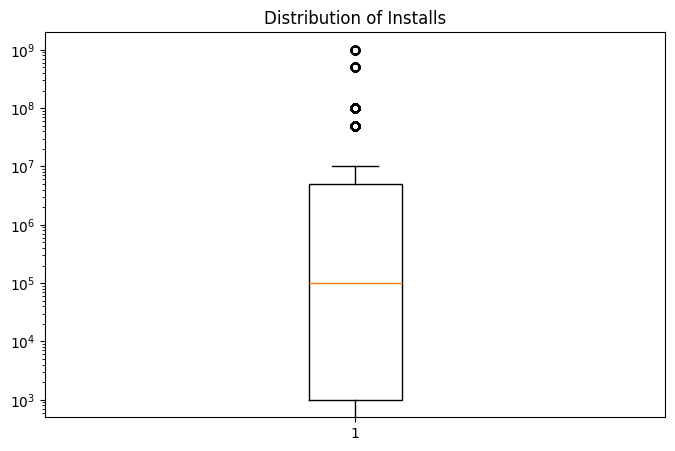

In [64]:
plt.figure(figsize=(8,5))

plt.boxplot(df['Installs'].dropna())

plt.yscale('log')
plt.title("Distribution of Installs")
plt.show()

Which genre contains the largest number of apps?

In [65]:
genre_counts = df['Genres'].value_counts()

genre_counts.head(20)

Genres
Tools                842
Entertainment        623
Education            549
Medical              463
Business             460
Productivity         424
Sports               398
Personalization      392
Communication        387
Lifestyle            381
Finance              366
Action               365
Health & Fitness     341
Photography          335
Social               295
News & Magazines     283
Shopping             260
Travel & Local       257
Dating               234
Books & Reference    231
Name: count, dtype: int64

In [ ]:
Does higher price imply higher ratings? 

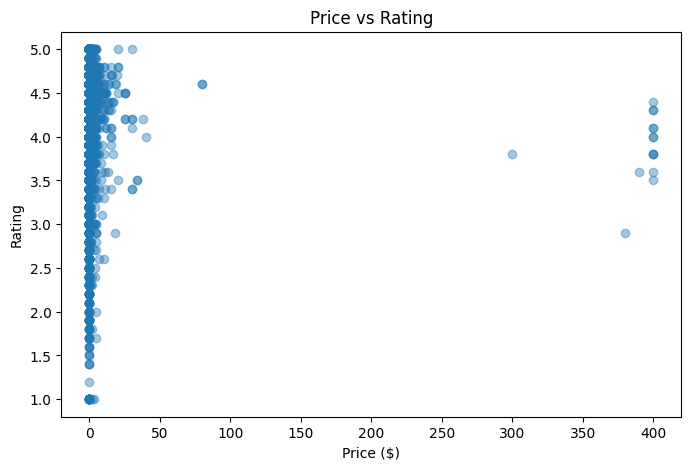

           Price    Rating
Price   1.000000 -0.021903
Rating -0.021903  1.000000


In [66]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Price'],
    df['Rating'],
    alpha=0.4
)

plt.xlabel("Price ($)")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

print(df[['Price','Rating']].corr())

Which app is the most expensive?

In [67]:
df.loc[df['Price'].idxmax()]

App               I'm Rich - Trump Edition
Category                         LIFESTYLE
Rating                                 3.6
Reviews                              275.0
Size                                   7.3
Installs                           10000.0
Type                                  Paid
Price                                400.0
Content Rating                    Everyone
Genres                           Lifestyle
Last Updated           2018-05-03 00:00:00
Current Ver                          1.0.1
Android Ver                     4.1 and up
App Age                               97.0
Name: 4367, dtype: object

Which category generates the highest total revenue potential?

Category
FAMILY             1.860526e+08
LIFESTYLE          5.758394e+07
GAME               4.098764e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        2.092277e+07
MEDICAL            1.357484e+07
PERSONALIZATION    1.027695e+07
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Revenue Potential, dtype: float64


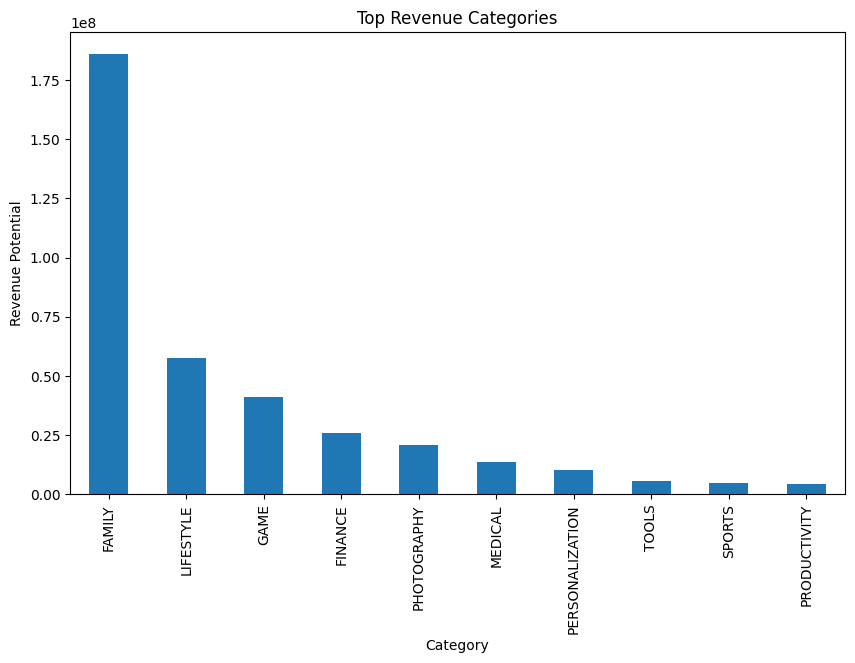

In [68]:
df['Revenue Potential'] = df['Price'] * df['Installs']

revenue = (
    df.groupby('Category')['Revenue Potential']
      .sum()
      .sort_values(ascending=False)
)

print(revenue.head(10))

plt.figure(figsize=(10,6))
revenue.head(10).plot(kind='bar')
plt.ylabel("Revenue Potential")
plt.title("Top Revenue Categories")
plt.show()

Does price affect installs?

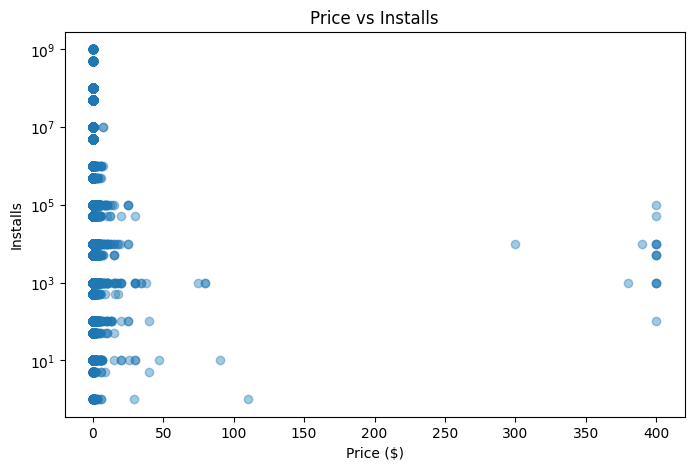

             Price  Installs
Price     1.000000 -0.011689
Installs -0.011689  1.000000


In [69]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Price'],
    df['Installs'],
    alpha=0.4
)

plt.yscale('log')

plt.xlabel("Price ($)")
plt.ylabel("Installs")
plt.title("Price vs Installs")
plt.show()

print(df[['Price','Installs']].corr())

Do paid apps receive more reviews than free apps?

Type
0                 NaN
Free    478661.096026
Paid     11673.312500
Name: Reviews, dtype: float64


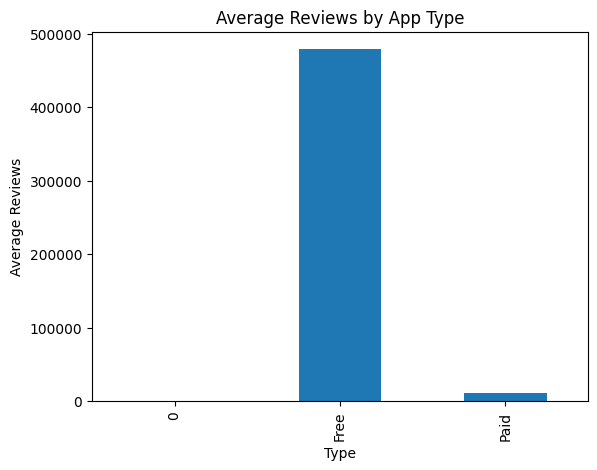

In [70]:
review_compare = (
    df.groupby('Type')['Reviews']
      .mean()
)

print(review_compare)

review_compare.plot(kind='bar')

plt.ylabel("Average Reviews")
plt.title("Average Reviews by App Type")
plt.show()

What percentage of apps cost more than $10? and Figure out some other pricing ranges?

Apps costing more than $10: 0.82%
Price
Free       10040
$1-$5        464
$0-$1        151
$5-$10        96
$10-$50       65
$50+          24
Name: count, dtype: int64


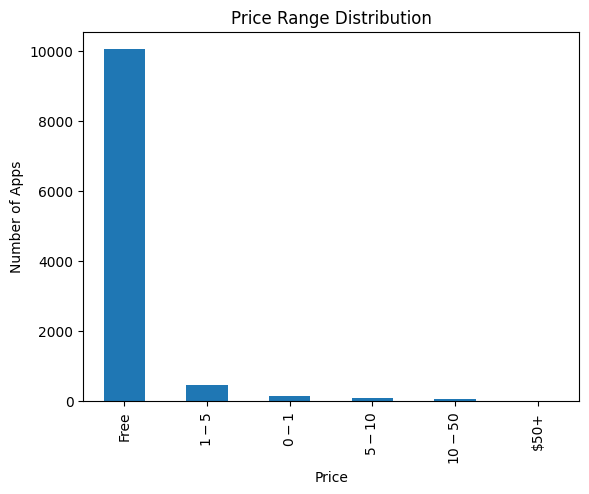

In [71]:
percent = (df['Price'] > 10).mean() * 100

print(f"Apps costing more than $10: {percent:.2f}%")

price_ranges = pd.cut(
    df['Price'],
    bins=[-1, 0, 1, 5, 10, 50, 500],
    labels=[
        "Free",
        "$0-$1",
        "$1-$5",
        "$5-$10",
        "$10-$50",
        "$50+"
    ]
)

print(price_ranges.value_counts())

price_ranges.value_counts().plot(kind='bar')

plt.title("Price Range Distribution")
plt.ylabel("Number of Apps")
plt.show()

Is there a relationship between app size and price?

In [72]:
percent = (df['Price'] > 10).mean() * 100

print(f"Apps costing more than $10: {percent:.2f}%")

price_bins = pd.cut(
    df['Price'],
    bins=[-0.01,0,1,5,10,50,500],
    labels=["Free","0-1","1-5","5-10","10-50","50+"]
)

print(price_bins.value_counts())

Apps costing more than $10: 0.82%
Price
Free     10040
1-5        464
0-1        151
5-10        96
10-50       65
50+         24
Name: count, dtype: int64


In which year were the most apps updated?

In [74]:
df["Update Year"] = df["Last Updated"].dt.year

update_counts = df["Update Year"].value_counts().sort_index()

update_counts

Update Year
2010.0       1
2011.0      15
2012.0      26
2013.0     110
2014.0     209
2015.0     459
2016.0     804
2017.0    1867
2018.0    7349
Name: count, dtype: int64

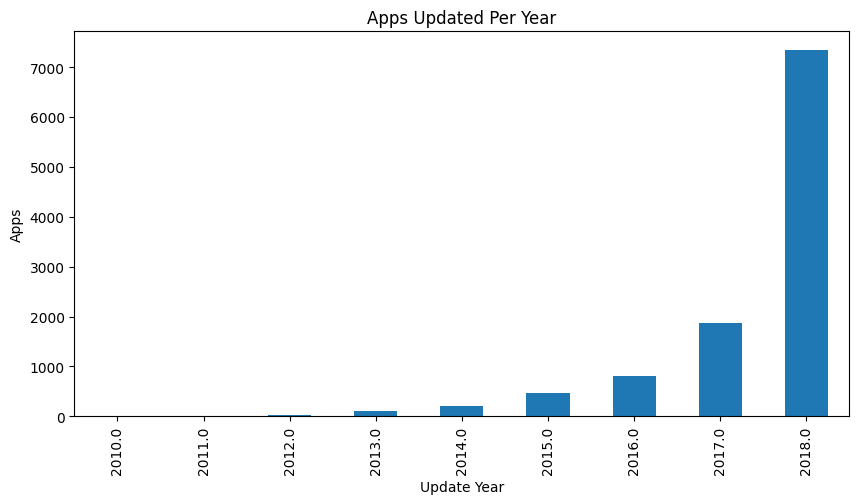

In [75]:
plt.figure(figsize=(10,5))

update_counts.plot(kind="bar")

plt.ylabel("Apps")
plt.title("Apps Updated Per Year")

plt.show()

Have app ratings improved over the years?

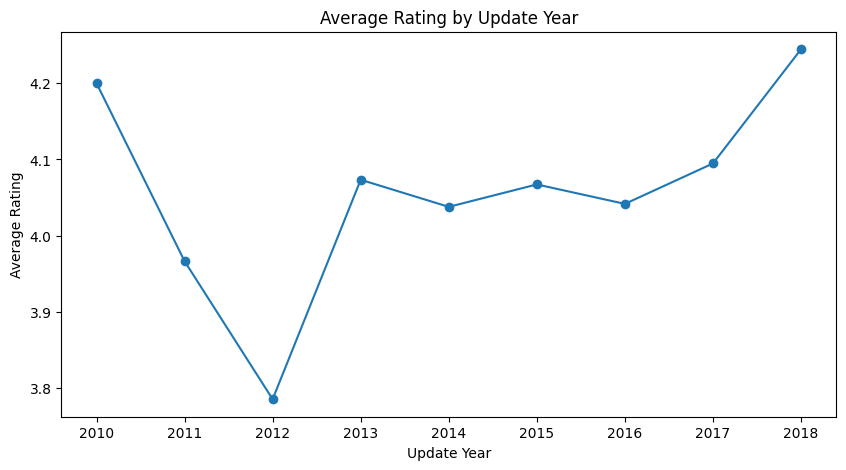

In [76]:
year_rating = (
    df.groupby("Update Year")["Rating"]
      .mean()
)

year_rating.plot(marker="o", figsize=(10,5))

plt.ylabel("Average Rating")
plt.title("Average Rating by Update Year")

plt.show()

What proportion of apps have not been updated in the last two years?

In [77]:
latest = df["Last Updated"].max()

old_apps = (
    (latest - df["Last Updated"]).dt.days > 730
)

print(f"{old_apps.mean()*100:.2f}%")

11.45%


Which content rating has the highest average rating?

In [78]:
content_rating = (
    df.groupby("Content Rating")["Rating"]
      .mean()
      .sort_values(ascending=False)
)

content_rating

Content Rating
Adults only 18+    4.300000
Everyone 10+       4.257179
Teen               4.233487
Everyone           4.186375
Mature 17+         4.123427
Unrated            4.100000
Name: Rating, dtype: float64

Which categories have many outdated apps?

In [79]:
outdated = (
    df.assign(
        Old=(latest-df["Last Updated"]).dt.days > 730
    )
    .groupby("Category")["Old"]
    .sum()
    .sort_values(ascending=False)
)

outdated.head(10)

Category
FAMILY                 280
GAME                   152
TOOLS                  139
PERSONALIZATION         91
MEDICAL                 53
PRODUCTIVITY            53
BUSINESS                53
LIFESTYLE               51
BOOKS_AND_REFERENCE     49
COMMUNICATION           48
Name: Old, dtype: int64

Which content rating gets the most reviews?

In [80]:
review_content = (
    df.groupby("Content Rating")["Reviews"]
      .sum()
      .sort_values(ascending=False)
)

review_content

Content Rating
Everyone           2.801847e+09
Teen               1.131524e+09
Everyone 10+       6.839972e+08
Mature 17+         1.971665e+08
Adults only 18+    8.134800e+04
Unrated            1.187000e+03
Name: Reviews, dtype: float64

Are Mature 17+ apps generally more expensive?

In [81]:
df.groupby("Content Rating")["Price"].mean().sort_values(ascending=False)

Content Rating
Everyone           1.171173
Teen               0.543278
Everyone 10+       0.378478
Mature 17+         0.236673
Adults only 18+    0.000000
Unrated            0.000000
Name: Price, dtype: float64

Which genre contains the most expensive apps?

In [82]:
genre_price = (
    df.groupby("Genres")["Price"]
      .max()
      .sort_values(ascending=False)
)

genre_price.head(20)

Genres
Lifestyle            400.00
Finance              399.99
Entertainment        399.99
Medical              200.00
Productivity         154.99
Events               109.99
Business              89.99
Education             39.99
Photography           29.99
Sports                29.99
Tools                 25.99
Communication         19.99
Role Playing          19.99
Arcade                17.99
Action                16.99
Casual                14.99
Casino                14.00
Social                13.99
Simulation            12.99
Maps & Navigation     11.99
Name: Price, dtype: float64

# Relationship Analysis
    Relationship between Reviews and Installs?



    Relationship between Price and Installs?



    Relationship between Size and Rating?



    Relationship between Reviews and Rating?



    Relationship between Size and Installs?



    Relationship between Price and Reviews?



    Relationship between App Size and Revenue Potential?

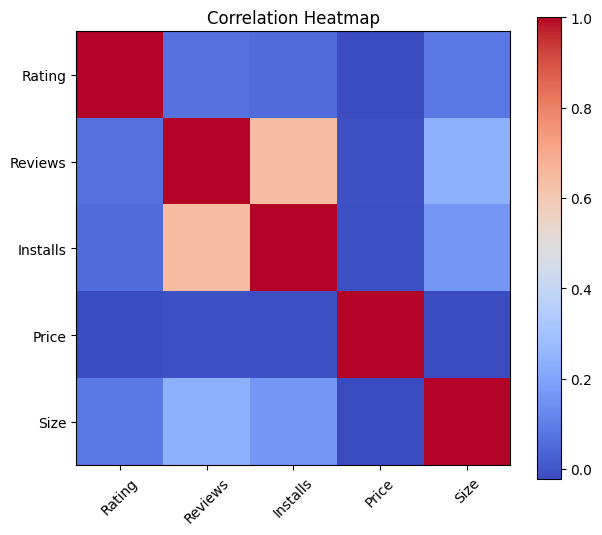

In [83]:
corr = df[
    ["Rating","Reviews","Installs","Price","Size"]
].corr()

plt.figure(figsize=(7,6))

plt.imshow(corr, cmap="coolwarm")

plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

Do free and paid apps have significantly different ratings?

In [85]:
from scipy.stats import ttest_ind

free = df[df.Type=="Free"]["Rating"].dropna()
paid = df[df.Type=="Paid"]["Rating"].dropna()

stat,p = ttest_ind(free,paid,equal_var=False)

print(stat,p)

-3.619962711026508 0.00031493066170592627


Are Type and Content Rating independent?

In [94]:
df["Review Ratio"] = (
    df["Reviews"] /
    df["Installs"]
)


df["Review Ratio"] = df["Review Ratio"].fillna(0)
df["Review Ratio"]

0        0.015900
1        0.001934
2        0.017502
3        0.004313
4        0.009670
           ...   
10836    0.007600
10837    0.040000
10838    0.003000
10839    0.114000
10840    0.039831
Name: Review Ratio, Length: 10841, dtype: float64

Create a Revenue Potential feature
use Revenue = Price × Installs

Which category has the highest revenue potential?

Create a Review-to-Install Ratio:

Review_Ratio = Reviews / Installs



In [93]:
df["Review Ratio"] = (
    df["Reviews"] /
    df["Installs"]
)

df["Review Ratio"] = df["Review Ratio"].fillna(0)
df["Review Ratio"]

0        0.015900
1        0.001934
2        0.017502
3        0.004313
4        0.009670
           ...   
10836    0.007600
10837    0.040000
10838    0.003000
10839    0.114000
10840    0.039831
Name: Review Ratio, Length: 10841, dtype: float64

Which apps have the most engaged users?

In [89]:
df[
["App","Review Ratio"]
].sort_values(
"Review Ratio",
ascending=False
).head(20)

,App,Review Ratio
4550,RMEduS - 음성인식을 활용한 R 프로그래밍 실습 시스템,4.0000
2454,KBA-EZ Health Guide,4.0000
8591,DN Blog,2.0000
10697,Mu.F.O.,2.0000
5812,AX Watch for WatchMaker,2.0000
5917,Ra Ga Ba,2.0000
9096,DZ Puzzle,1.4000
6700,Brick Breaker BR,1.4000
6508,Sam.BN Pro,1.1000
7402,Trovami se ci riesci,1.1000


Create an App Age feature:

App_Age = Current Year − Last Updated Year

In [95]:
latest = df["Last Updated"].max()

df["App Age"] = (
latest-df["Last Updated"]
).dt.days

df[["App","App Age"]].head()

,App,App Age
0,Photo Editor & Candy Camera & Grid & ScrapBook,213.0
1,Coloring book moana,205.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",7.0
3,Sketch - Draw & Paint,61.0
4,Pixel Draw - Number Art Coloring Book,49.0


Do newer apps perform better?

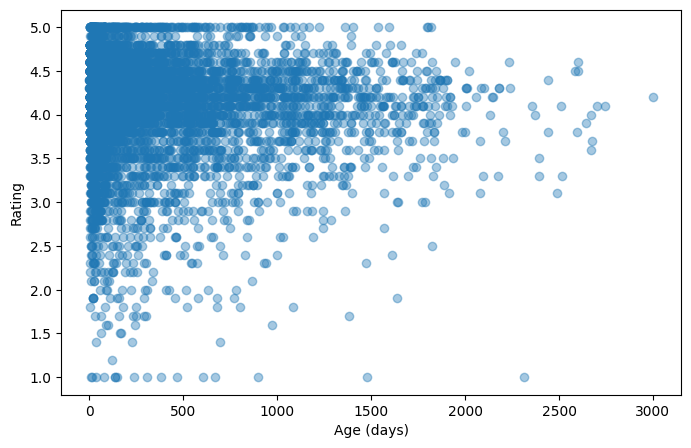

          App Age    Rating
App Age  1.000000 -0.142791
Rating  -0.142791  1.000000


In [96]:
plt.figure(figsize=(8,5))

plt.scatter(
df["App Age"],
df["Rating"],
alpha=.4
)

plt.xlabel("Age (days)")
plt.ylabel("Rating")

plt.show()

print(df[
["App Age","Rating"]
].corr())

Create a Success Index:

Success_Index =
0.2 × Normalized Rating +
0.4 × Normalized Installs +
0.3 × Normalized Reviews



In [100]:
df["Success Index"] = (
0.5*df["Rating"].fillna(0)
+
0.3*np.log1p(df["Installs"])
+
0.2*np.log1p(df["Reviews"])
)
df["Success Index"] 

0         5.828167
1         7.261756
2         9.253389
3        10.024538
4         6.978927
           ...    
10836     5.537930
10837     4.206424
10838     2.349885
10839     5.271613
10840     9.664425
Name: Success Index, Length: 10841, dtype: float64

Which apps are the most successful?

In [101]:
df[
["App","Success Index"]
].sort_values(
"Success Index",
ascending=False
).head(20)

,App,Success Index
2604,Instagram,12.069755
2545,Instagram,12.069755
2611,Instagram,12.069755
3909,Instagram,12.069552
336,WhatsApp Messenger,12.027249
381,WhatsApp Messenger,12.027249
3904,WhatsApp Messenger,12.027221
2544,Facebook,11.901829
3943,Facebook,11.901752
1917,Subway Surfers,11.894551


Do free apps with in-app purchases (inferred from low price + high reviews) outperform truly free apps in terms of rating and installs?

In [102]:
free = df[df["Price"]==0]

cheap = df[
(df["Price"]>0)&
(df["Price"]<=1)
]

comparison = pd.DataFrame({
"Free Rating":[free["Rating"].mean()],
"Cheap Rating":[cheap["Rating"].mean()],
"Free Reviews":[free["Reviews"].mean()],
"Cheap Reviews":[cheap["Reviews"].mean()]
})

comparison

,Free Rating,Cheap Rating,Free Reviews,Cheap Reviews
0,4.186203,4.300917,478613.420618,6606.602649


Which categories show the steepest "update fatigue" — apps that were last updated 2+ years ago but still have high install counts?

In [103]:
fatigue = df[
(df["App Age"]>730)
&
(df["Installs"]>1_000_000)
]

fatigue.groupby(
"Category"
).size().sort_values(
ascending=False
)

Category
GAME                   30
FAMILY                 17
TOOLS                  12
PHOTOGRAPHY            10
VIDEO_PLAYERS           6
PERSONALIZATION         6
COMMUNICATION           5
SOCIAL                  4
PRODUCTIVITY            4
LIBRARIES_AND_DEMO      4
LIFESTYLE               3
BOOKS_AND_REFERENCE     2
ENTERTAINMENT           2
SPORTS                  1
TRAVEL_AND_LOCAL        1
dtype: int64

Do apps that launched earlier (older Last Updated year) show declining ratings over time

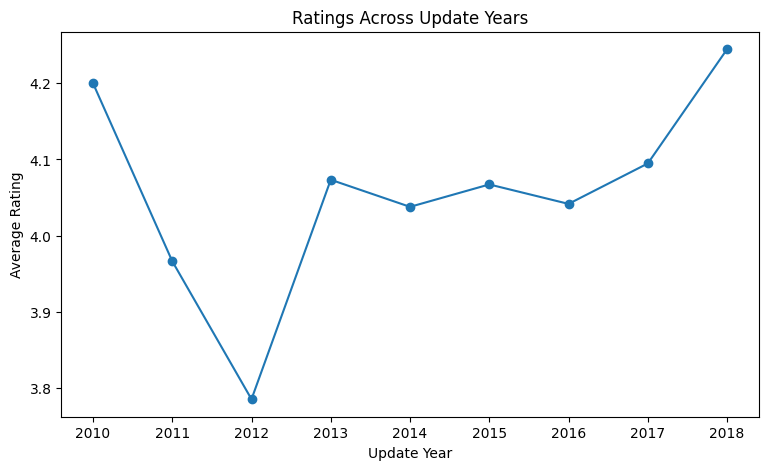

In [104]:
trend = (
df.groupby("Update Year")["Rating"]
.mean()
)

trend.plot(
marker="o",
figsize=(9,5)
)

plt.ylabel("Average Rating")
plt.title("Ratings Across Update Years")

plt.show()